# Intro and theory 

##  В этом блокноте аппроксимируется '$\epsilon(\omega)$ по спектрам отражения и пропускания пленок графена разной толщины на полипропиленовой подложке  
 $\epsilon$ воздуха = 1.00027717
```
показатель преломления полипропилена = 1.498+i*14e-4
```                   
<blockquote>
    толщина полипропилена = 40 мкм
    толщина 1 слоя графена = 35 нм
</blockquote> 


Котликов, 2021
1) задача определения параметров пленки по спектрам отражения и пропускания является типичной `некорректной` обратной задачей синтеза, не имеющей однозначного решения. Ее решение существенно зависит от наличия априорной информации о специфических особенностях исследуемых пленок и выбора метода решения.

$\epsilon$ re im независимые

Основная проблема - выбор числа точек регрессии, чтобы минимизировать случайную погрешность и изменение $\epsilon(\omega)$

Вопросы:
1) поглощение, R+T!=1? (учтено поглощение, но не рассеяние)
2) нельзя поляризовать под углом брюстера?

При больших длинах волн  

Уханов: конспект экспериментальных методов

брать табличное значение полипропилена 

аппроксимировать от перегиба до перегиба 

толщина - параметр при аппроксимации: лучше ли точность аппроксимации при большой толщине?

попробовать прямую задачу:  различные значения параметров (в ручную), возможно с явной формулой через многокр. отр. с приближение однократным (нулевой угол проще)

определить изм. пок. прел. если разделить спектры на полипропилен
![reflection_data](./reflection_data.png)



# Init

In [3]:
# 1. Standard library imports
import sys, os
import glob
import re
import logging

# 2. Third-party library imports
import numpy as np
from numpy import pi, sqrt, sin, cos, arccos
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from scipy.optimize import curve_fit
from scipy.signal import argrelextrema

# 3. Local application/library specific imports

# Enable automatic reloading of modules when they change
%load_ext autoreload
%autoreload 2
%matplotlib inline

sys.path.append(r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\lib')
from reflect import *

from tmm import (
    coh_tmm, 
    unpolarized_RT, 
    ellips,
    position_resolved, 
    find_in_structure_with_inf, 
    list_snell
)
from non_polarized_VV import ref_tr_vv


In [4]:
#Show log messages from INFO 

logger = logging.getLogger('dispersion_fit')
if logger.handlers:
    logger.handlers = []
logger.setLevel(logging.DEBUG)

# Add a StreamHandler to the logger to output logs to the console
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)

# Create a formatter and set it for the handler
formatter = logging.Formatter('%(levelname)s - %(message)s')
console_handler.setFormatter(formatter)

# Add the handler to the logger
logger.addHandler(console_handler)

# test logs
logger.info("hsdjkh")
logger.debug("sdjql") 

INFO - hsdjkh
DEBUG - sdjql


# Constants

In [57]:
E_GR = 100+1j*100
THK = 35e-9
THK_PP = 40e-6
N_PP = 1.498+1j*14e-4
def fres_norm(n1, n2):
    return (n1-n2)/(n1+n2)
def delta(n, d, wl):
    return 2*pi*n*d/wl
WL_RANGE = np.array([0.01/50, 0.01/700])
N_GR = sqrt(E_GR)
r_01 = fres_norm(1, N_GR)
r_12 = fres_norm(N_GR, N_PP)
r_23 = fres_norm(N_PP, 1)
D1 = delta(N_GR, THK, WL_RANGE)
D2 = delta(N_PP, THK_PP, WL_RANGE)
EXP1 = np.exp(2j*pi*D1)
EXP2 = np.exp(2j*pi*D2)
logger.info(f"phase1: {D1}, phase2: {D2}")
logger.info(f"exp1: {EXP1}, exp2: {EXP2}")
logger.info(f"r_01: {r_01}, r_12: {r_12}, r_23: {r_23}")
logger.info(f"r_12*r_23={r_12*r_23}")
logger.info(f"r_01*r_23={r_01*r_23}")
logger.info(f"1+r_01*r_12={1+r_01*r_12}")
logger.info(f"r_01+r_12={r_01+r_12}")
logger.info(f"r_01*r_12*r_23+r_23={r_01*r_12*r_23+r_23}")
logger.info(f"r_01+r_12+r_23+r_01*r_12*r_23={r_01+r_12+r_23+r_01*r_12*r_23}")
logger.debug(f"2.4-1.6*N_PP={2.4-1.6*N_PP}")
logger.debug(f"")
logger.debug(f"")
WL_ARR = np.linspace(50, 700, 651)
def R_COEF(E):
    pass


INFO - phase1: [0.01208066+0.00500397j 0.16912928+0.07005564j], phase2: [ 1.88244232+0.00175929j 26.35419245+0.02463009j]
INFO - exp1: [0.96625795+0.07348503j 0.31329581+0.56257045j], exp2: [ 0.73125898-0.6658791j  -0.52159017+0.67952156j]
INFO - r_01: (-0.8541702810064785-0.05536540088997577j), r_12: (0.7881174545231784+0.07703362869860257j), r_23: (0.1993597390730697+0.00044871752013518905j)
INFO - r_12*r_23=(0.15708432375383607+0.01571104622697404j)
INFO - r_01*r_23=(-0.17026232092003354-0.011420913045367874j)
INFO - 1+r_01*r_12=(0.3310784901387338-0.10943427509049711j)
INFO - r_01+r_12=(-0.06605282648330013+0.021668227808626803j)
INFO - r_01*r_12*r_23+r_23=(0.06605282648330027-0.021668227808626876j)
INFO - r_01+r_12+r_23+r_01*r_12*r_23=(1.3877787807814457e-16-7.28583859910259e-17j)
DEBUG - 2.4-1.6*N_PP=(0.0031999999999996476-0.0022400000000000002j)
DEBUG - 
DEBUG - 


# Import and plot data

## Reflect

DEBUG - [('C:\\Users\\belco\\Documents\\Graphene\\Data\\Dispersion_PP_40\\Ref_dis\\PP+graphene-0.5_layer_reflectance_45_deg_0.dpt', '18 нм'), ('C:\\Users\\belco\\Documents\\Graphene\\Data\\Dispersion_PP_40\\Ref_dis\\PP+graphene-1_layer_reflectance_45_deg_0.dpt', '35 нм'), ('C:\\Users\\belco\\Documents\\Graphene\\Data\\Dispersion_PP_40\\Ref_dis\\PP+graphene-2_layers_reflectance_45_deg_0.dpt', '70 нм'), ('C:\\Users\\belco\\Documents\\Graphene\\Data\\Dispersion_PP_40\\Ref_dis\\PP+graphene-3_layers_reflectance_45_deg_0.dpt', '105 нм'), ('C:\\Users\\belco\\Documents\\Graphene\\Data\\Dispersion_PP_40\\Ref_dis\\PP+graphene-4_layers_reflectance_45_deg_0.dpt', '140 нм'), ('C:\\Users\\belco\\Documents\\Graphene\\Data\\Dispersion_PP_40\\Ref_dis\\PP+graphene-5_layers_reflectance_45_deg_1_0.dpt', '176 нм'), ('C:\\Users\\belco\\Documents\\Graphene\\Data\\Dispersion_PP_40\\Ref_dis\\PP_layer_reflectance_45_deg_0.dpt', 'ПП')]
DEBUG - [(39.5437292255, 0.1914165765), (40.5082104261, 0.1935330331), (41.47

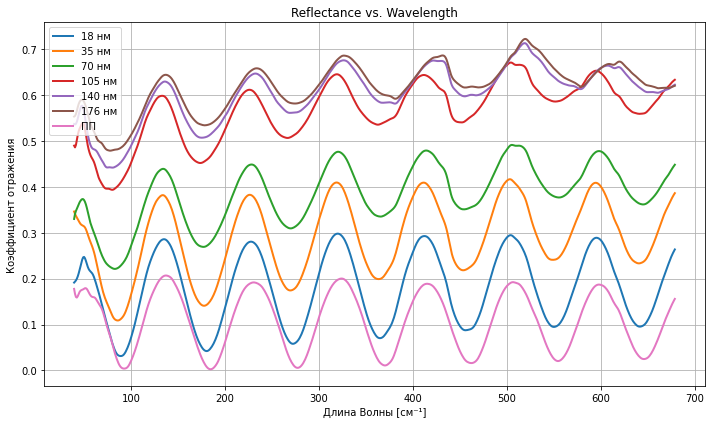

In [30]:
def load_r_data(path, 
                draw_plot=True,
                extension = '.dpt',
                thk_arr_rf = np.array([0.5, 1, 2, 3, 4, 5, 0])*35e-9,
                labels = ['18 нм', '35 нм', '70 нм', '105 нм', '140 нм', '176 нм', 'ПП'],
                reverse=True):
    
    """
    Check correspondence between curves and labels
    """

    # Step 1: Load all 7 files into a list
    file_paths = glob.glob(path + '/*' + extension)

    # Create a new figure with specified size (width=10, height=6 inches)
    plt.figure(figsize=(10, 6))

    
    
    # Thickness list in meters
    

    logger.debug(f"{list(zip(file_paths, labels))}")

    from collections import namedtuple
    
    # First 'ReflectData' is the variable name, second 'ReflectData' is the type name for the namedtuple
    reflect_dict = {}


    # Step 3: Loop through files and plot each
    for i, file in enumerate(file_paths):
        data = pd.read_csv(file, header=None, sep='\t', decimal='.')  # Read file assuming no header
        # if reversed wavelength array 
        if reverse:
            R_wavelength_rc = data[0][::-1]  # First column: Wavelength [cm⁻¹], [::-1] for ascending sort 
            reflectance = data[1][::-1]  # Second column: Reflectance R. [::-1] for ascending sort 
        if not reverse:
            R_wavelength_rc = data[0] 
            reflectance = data[1]
        assert len(R_wavelength_rc)==len(reflectance) 
        reflect_dict[file] = (R_wavelength_rc, reflectance, thk_arr_rf[i])
        if draw_plot:
            plt.plot(R_wavelength_rc, reflectance, 
            label=labels[i], 
            linewidth=2)  # Plot with label
        

        logger.debug(f"{list(zip(R_wavelength_rc, reflectance))}")


        # Step 4: Customize the plot
    plt.xlabel("Длина Волны [см⁻¹]")
    plt.ylabel("Коэффициент отражения")
    plt.title("Reflectance vs. Wavelength")
    plt.legend()  # Add legend for dataset distinction
    plt.grid()  # Optional: Add grid
    plt.tight_layout()
        # Step 5: Display the plot
    plt.savefig("reflection_data.png", dpi=300)    
    plt.show()
 
    return reflect_dict




reflect_dict = load_r_data(r'C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Ref_dis')



## Transmit

DEBUG - [('C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis\\PP-40 um+graphene-0.5L_transmittance.0.dpt', '18 нм'), ('C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis\\PP-40 um+graphene-1L_transmittance.0.dpt', '35 нм'), ('C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis\\PP-40 um+graphene-2L_transmittance.0.dpt', '70 нм'), ('C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis\\PP-40 um+graphene-3L_transmittance.0.dpt', '105 нм'), ('C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis\\PP-40 um+graphene-4L_transmittance.0.dpt', '140 нм'), ('C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis\\PP-40 um+graphene-5L_transmittance.0.dpt', '176 нм'), ('C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis\\PP-40 um_transmittance.0.dpt', 'ПП')]
DEBUG - [(39.5437292255, 0.6996741295), (40.5082104261, 0.6808163524), (41.4726916268, 0.6746255159), (42.4371728274, 0.682634294), (43.4016

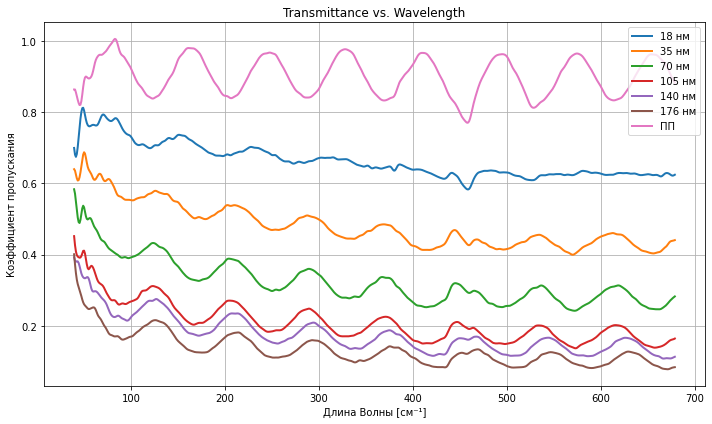

In [31]:
def load_t_data(path, 
                draw_plot=True,
                extension = '.dpt',
                thk_arr_rf = np.array([0.5, 1, 2, 3, 4, 5, 0])*35e-9,
                labels = ['18 нм',  '35 нм', '70 нм', '105 нм', '140 нм', '176 нм', 'ПП'], 
                reverse = True):
    
    """
    ! Check that labels correspond to thicknesses
    """

    # Step 1: Load all 7 files into a list
    file_paths = glob.glob(path + '/*dpt')

    logger.debug(f"{list(zip(file_paths, labels))}")

    # Step 2: Initialize a plot
    plt.figure(figsize=(10, 6))
    

    transmit_dict = {}


    # Step 3: Loop through files and plot each
    for i, file in enumerate(file_paths):
        data = pd.read_csv(file, header=None, sep='\t', decimal='.')  # Read file assuming no header
        transmit_dict[file] = data
        if reverse:
            T_wavelength = data[0][::-1]  # First column: Wavelength [cm⁻¹]   
            transmittance = data[1][::-1] # Second column: Reflectance R   
        if not reverse:
            T_wavelength = data[0]   
            transmittance = data[1] 
        transmit_dict[file] = (T_wavelength, transmittance, thk_arr_rf[i])
        if draw_plot:
            plt.plot(T_wavelength, transmittance, label = labels[i], linewidth=2)  # Plot with label

        logger.debug(list(zip(T_wavelength, transmittance)))

    # Step 4: Customize the plot
    plt.xlabel("Длина Волны [см⁻¹]")
    plt.ylabel("Коэффициент пропускания")
    plt.title("Transmittance vs. Wavelength")
    plt.legend()  # Add legend for dataset distinction
    plt.grid(True)  # Optional: Add grid
    plt.tight_layout()

    # Step 5: Display the plot
    plt.show()
    return transmit_dict

transmit_dict = load_t_data(r"C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis")

# Testing Gerasimov's and tmm functions 

In [ ]:
# Check if VV and tmm are equal

def test_angle_vv_tmm():
    # (air, graphene, PP, air)
    n_list = np.array([1, np.sqrt(-17+700*1j), 1.498+1j*14e-4 , 1])
    eps_1, eps_2, eps_3, eps_4 = n_list**2
    for teta in [0, np.pi/4]:

        kz_1 = np.sqrt(eps_1) * np.cos(teta)
        kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
        kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)
        kz_4 = np.sqrt(eps_4 - eps_1 * np.sin(teta)**2)
        kz_vv = np.array([kz_1, kz_2, kz_3, kz_4])
        
        
        kz_tmm = np.array(2*np.pi*np.cos(list_snell(n_list, teta))*n_list/2/np.pi)
        print(kz_vv, '\n', kz_tmm, '\n')
        assert np.all(np.abs(kz_tmm-kz_vv))<1e-6

test_angle_vv_tmm()
    

In [ ]:
# try VV

def test_VV_tmm():

    wls_rc = np.linspace(100, 700, 601)
    wls = 0.01/wls_rc
    T = ref_tr_vv(wls, 0, -17+700*1j, 35e-9)['T']
    
   
    def non_polarized_tmm(*args):
        return 0.5*(coh_tmm('s', *args)['T']+coh_tmm('p', *args)['T'])
    
    n_list = [1, np.sqrt(-17+700*1j), 1.498+1j*14e-4 , 1]
    d_list =  [np.inf, 35e-9, 40.5e-6, np.inf]
    T2 = np.array([non_polarized_tmm(n_list, d_list, 0, wl) for wl in wls])
    print(T-T2)
    plt.plot(wls_rc, T2-T)
    plt.show()
    assert np.all(np.abs(T-T2)<1e-4)
    
test_VV_tmm()

# Approximation of polypropylene $\epsilon$

In [ ]:
# find epsilon of PP assuming extiction=0
def find_PP_n():
    filename = r'C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Ref_dis\PP_layer_reflectance_45_deg_0.dpt'
    d = 40.5e-6
    wl_rc_range = reflect_dict[filename][0].to_numpy()
    R_range = reflect_dict[filename][1].to_numpy()
    min_indices = argrelextrema(R_range, np.greater)
    wls_max = 0.01/ wl_rc_range[min_indices][::-1]
    n = [wl1*wl2/(2*d*(wl2-wl1)) for wl1, wl2 in zip(wls_max, wls_max[1:])]
    print(list(zip(wls_max, wls_max[1:])), '\n', n)
    return np.average(n)
find_PP_n()

# Fit functions

## Static window fit function

In [32]:

# i - window, j - window step 
def make_2d_windows_vectorized(arr, i, j):
    n = len(arr)
    # Number of rows we can take
    num_rows = (n - i) // j + 1 if n >= i else 0
    
    # Create row and column offsets
    row_offsets = np.arange(num_rows)[:, None] * j  # shape (num_rows, 1)
    col_offsets = np.arange(i)                      # shape (i,)
    
    # Broadcast-add to get the 2D index array
    # shape (num_rows, i)
    indices = row_offsets + col_offsets
    
    return arr[indices]

make_2d_windows_vectorized(np.arange(13), 11, 56)


array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]])

In [33]:
# Try tmm for fitting
def create_fit_function(gr_thk, mode):

    """ with polypropylene film """
    
    def fit_reflect(wl_rcp_arr, ngr_re, ngr_im):
        wl_arr = 0.01/wl_rcp_arr
        n_list=[1, ngr_re+ 1j*ngr_im, 1.498+1j*14e-4 , 1]
        d_list=[np.inf, gr_thk, 40.5e-6, np.inf]
        
        rf_s = np.array([coh_tmm(pol='s', n_list=n_list, d_list=d_list, th_0=np.pi/4, lam_vac=wl)['R'] 
                for wl in wl_arr])
        rf_p = np.array([coh_tmm(pol='p', n_list=n_list, d_list=d_list, th_0=np.pi/4, lam_vac=wl)['R'] 
                for wl in wl_arr])
        result = 0.5*(rf_s+rf_p)
        
        # try VV
        #result = ref_tr_vv(wl_arr, np.pi/4, ngr_re+ngr_im*1j, gr_thk)['R']

        return result

    def fit_transmit(wl_rcp_arr, ngr_re, ngr_im):

        wl_arr = 0.01/wl_rcp_arr
        n_list=[1, ngr_re+ 1j*ngr_im, 1.498+1j*14e-4 , 1]
        d_list=[np.inf, gr_thk, 40.5e-6, np.inf]

        rf_s = np.array([coh_tmm(pol='s', n_list=n_list, d_list=d_list, th_0=0, lam_vac=wl)['T']
                for wl in wl_arr])
        rf_p = np.array([coh_tmm(pol='p', n_list=n_list, d_list=d_list,th_0=0, lam_vac=wl)['T']
                for wl in wl_arr])
        result = 0.5*(rf_s+rf_p)
        return result
    
    if (mode == 'R'):
        return fit_reflect
    if (mode == 'T'):
        return fit_transmit



# Inflection points approach

In [ ]:
# inflection points approach

from scipy.signal import savgol_filter

def find_inflection_points_noisy(arr, window_length=50, polyorder=3, threshold=1e-5):
    """
    Given a noisy 1D numpy array 'arr', return indices that correspond to 
    inflection points. The function first smooths the data and computes a 
    smoothed second derivative using a Savitzky–Golay filter.
    
    Parameters:
      arr           : Input array (discrete function)
      window_length : Length of the filter window (must be odd)
      polyorder     : Order of the polynomial used in filtering
      threshold     : Minimum absolute change in the second derivative to consider a true inflection
      
    Returns:
      inflection_indices : numpy array of indices where inflection occurs.
    """
    # Smooth the array; you can also smooth directly the derivatives.
    smoothed = savgol_filter(arr, window_length=window_length, polyorder=polyorder)
    # Compute the second derivative from the smoothed data
    d2 = savgol_filter(smoothed, window_length=window_length, polyorder=polyorder, deriv=2)
    
    inflec = []
    # Loop over indices in d2. d2[i] corresponds to the second derivative at index i.
    for i in range(len(d2)-1):
        # Check for a sign change and that the change is significant
        if d2[i] * d2[i+1] < 0 and np.abs(d2[i] - d2[i+1]) > threshold:
            inflec.append(i+1)
    return np.array(inflec, dtype=int)

def segment_by_inflection_noisy(arr, window_length=11, polyorder=3, threshold=1e-5):
    """
    Segment a 1D noisy array 'arr' using inflection points detected on its smoothed second derivative.
    The endpoints of the array are also used as boundaries.
    
    Returns:
      segments   : List of sub-arrays (segments)
      boundaries : Array of boundary indices.
    """
    inflection_indices = find_inflection_points_noisy(arr, window_length, polyorder, threshold)
    # Include endpoints
    boundaries = np.concatenate(([0], inflection_indices, [len(arr)-1]))
    boundaries = np.unique(boundaries)  # ensure sorted and unique
    segments = []
    for i in range(len(boundaries) - 1):
        start = boundaries[i]
        end = boundaries[i+1] + 1  # include the boundary point in the segment
        segments.append(arr[start:end])
    return segments, boundaries

# Example usage with noisy data:
if __name__ == '__main__':
    # Create a sample function: for example, a sine with a quadratic trend, plus random noise.
    x = np.linspace(0, 10, 200)
    true_f = np.sin(x) + 0.1 * x**2
    noise = np.random.normal(0, 0.1, x.shape)
    noisy_f = true_f + noise

    # Find inflection points and segments using the noisy data
    segments, boundaries = segment_by_inflection_noisy(noisy_f, window_length=11, polyorder=3, threshold=5e-3)
    
    print("Inflection point indices (boundaries):", boundaries)
    print("Number of segments:", len(segments))
    
    # Plot results
    plt.figure(figsize=(8, 4))
    #plt.plot(x, noisy_f, label='Noisy f(x)', color='blue')
    plt.plot(x, true_f, label='True f(x)', linestyle='--', color='black')
    plt.plot(x[boundaries], noisy_f[boundaries], 'ro', label='Inflection Boundaries')
    for i, (start, end) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        plt.axvspan(x[start], x[end], alpha=0.2, label='Segment' if i==0 else None)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.title("Segmentation by Inflection Points (with Noise)")
    plt.show()


## Dynamic segmentation approach

In [ ]:
# ---------------------------
# Generate synthetic spectral data
# ---------------------------
# Define wavelength range (e.g., in nm)
lam = np.linspace(400, 800, 1000)  # 1000 points from 400 to 800 nm

# True refractive index functions (for demonstration)
n_true = 1.5 + 0.2 * np.sin(0.01 * lam)      # e.g. oscillatory behavior in n(λ)
k_true = 0.01 + 0.005 * np.cos(0.01 * lam)     # similar behavior for k(λ)

# Add random noise to simulate experimental error
np.random.seed(0)
noise_level = 0.001  # noise level for both n and k
n_data = n_true + np.random.normal(0, noise_level, lam.shape)
k_data = k_true + np.random.normal(0, noise_level, lam.shape)

# ---------------------------
# Compute derivative of n_data with respect to lam
# ---------------------------
# We use a finite-difference approximation (numpy.gradient)
deriv_n = np.gradient(n_data, lam)

# Experimental error tolerance (epsilon)
epsilon = 0.001  # allowable change in n over a segment

# For cases where the derivative is nearly zero, we set a maximum segment length.
max_segment_length = 50.0  # nm

# ---------------------------
# Dynamic segmentation based on the criterion Δλ ≈ ε/|dn/dλ|
# ---------------------------
segments = []        # will store tuples: (wavelength segment, n_segment, k_segment)
segment_bounds = []  # to record the segment boundaries (start and end indices)

i = 0
while i < len(lam):
    seg_start = i
    # Estimate local derivative (absolute value) at the start of the segment
    local_deriv = np.abs(deriv_n[i])
    # If the derivative is very small, use a default max segment length
    if local_deriv < 1e-8:
        allowed_length = max_segment_length
    else:
        allowed_length = epsilon / local_deriv
        # Do not exceed a preset maximum length
        allowed_length = min(allowed_length, max_segment_length)
    
    # Determine the segment: include points until the wavelength difference exceeds allowed_length
    j = seg_start + 1
    while j < len(lam) and (lam[j] - lam[seg_start]) <= allowed_length:
        j += 1

    # Append this segment (use slicing from seg_start to j)
    segments.append((lam[seg_start:j], n_data[seg_start:j], k_data[seg_start:j]))
    segment_bounds.append((seg_start, j-1))
    i = j  # move to the next segment

print(f"Number of segments: {len(segments)}")

# ---------------------------
# Define a linear fitting function
# ---------------------------
def linear_func(x, a, b):
    return a * x + b

# Prepare arrays to hold fitted values for the entire wavelength range
fitted_n = np.zeros_like(n_data)
fitted_k = np.zeros_like(k_data)

# For each segment, fit a linear model and store the fitted values
for seg in segments:
    lam_seg, n_seg, k_seg = seg
    # Fit the linear model to n and k separately using curve_fit
    popt_n, _ = curve_fit(linear_func, lam_seg, n_seg)
    popt_k, _ = curve_fit(linear_func, lam_seg, k_seg)
    
    # Compute fitted values on the segment
    fitted_n_seg = linear_func(lam_seg, *popt_n)
    fitted_k_seg = linear_func(lam_seg, *popt_k)
    
    # Find indices corresponding to this segment and store the fitted values
    inds = np.searchsorted(lam, lam_seg)
    fitted_n[inds] = fitted_n_seg
    fitted_k[inds] = fitted_k_seg

# ---------------------------
# Plot the results
# ---------------------------
plt.figure(figsize=(12, 6))

# Plot for the real refractive index
plt.subplot(1, 2, 1)
plt.plot(lam, n_data, label="Noisy n_data", alpha=0.5)
plt.plot(lam, n_true, label="True n (model)", linestyle="--")
plt.plot(lam, fitted_n, label="Fitted n (dynamic segments)", linewidth=2)
# Mark segment boundaries
for (start, end) in segment_bounds:
    plt.axvline(lam[start], color='gray', linestyle=':', alpha=0.7)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Refractive Index n")
plt.title("Dynamic Spectral Fitting for n")
plt.legend()

# Plot for the extinction coefficient
plt.subplot(1, 2, 2)
plt.plot(lam, k_data, label="Noisy k_data", alpha=0.5)
plt.plot(lam, k_true, label="True k (model)", linestyle="--")
plt.plot(lam, fitted_k, label="Fitted k (dynamic segments)", linewidth=2)
# Mark segment boundaries
for (start, end) in segment_bounds:
    plt.axvline(lam[start], color='gray', linestyle=':', alpha=0.7)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Extinction Coefficient k")
plt.title("Dynamic Spectral Fitting for k")
plt.legend()

plt.tight_layout()
plt.show()


# Fitting procedure

## Only 1 layer approximation

In [ ]:
def fit_gr_thk_1_layer():
    filename = r'C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Ref_dis\PP+graphene-1_layer_reflectance_45_deg_0.dpt'
    x_data = reflect_dict[filename][0][290:380]
    y_data = reflect_dict[filename][1][290:380]
    #print(list(zip(x_data, y_data)))
    _popt, _pcov = curve_fit(fit_gr_thk_function, x_data, y_data, bounds=([1e-8, -np.inf, -np.inf],[1e-7, np.inf, np.inf]))
    _perr = np.sqrt(np.diag(_pcov))
    print('popt=', _popt,  'perr=', _perr, 'eps=', (_popt[1]+_popt[2]*1j)**2)
    #plt.plot(x_data, fit_reflect(x_data, _popt[0], _popt[1]), x_data, y_data)
    print(fit_gr_thk_function(x_data, 7e-8, 10, 10)-fit_gr_thk_function(x_data, 14e-8, 10, 10))
    plt.plot(x_data, y_data)
    plt.show()   

fit_gr_thk_1_layer()

    

## Fit Reflect

INFO - gr_thk= 1.75e-08m
DEBUG - (wl, R): [(39.5437292255, 0.1914165765), (40.5082104261, 0.1935330331), (41.4726916268, 0.1960917711), (42.4371728274, 0.1997106671), (43.401654028, 0.2047946006), (44.3661352286, 0.2111569643), (45.3306164293, 0.2184057683), (46.2950976299, 0.2262926996), (47.2595788305, 0.2345074266), (48.2240600311, 0.2417942733), (49.1885412317, 0.2464875877), (50.1530224324, 0.2473662347), (51.117503633, 0.2444466799), (52.0819848336, 0.2388885021), (53.0464660342, 0.232309714), (54.0109472349, 0.2261593938), (54.9754284355, 0.2213459462), (55.9399096361, 0.2180714756), (56.9043908367, 0.2158762962), (57.8688720373, 0.2139194608), (58.833353238, 0.2113857269), (59.7978344386, 0.2077893764), (60.7623156392, 0.203038007), (61.7267968398, 0.1973193884), (62.6912780405, 0.1909027994), (63.6557592411, 0.1842380613), (64.6202404417, 0.1775043458), (65.5847216423, 0.1706739813), (66.5492028429, 0.1636132002), (67.5136840436, 0.156234324), (68.4781652442, 0.1485776156), (6

DEBUG - Segment: wavelength range 39.5 to 135.0


popt= [19.99007322 15.56145761], perr= [0.38572874 0.59452325], wl_begin = 87.28554865634999


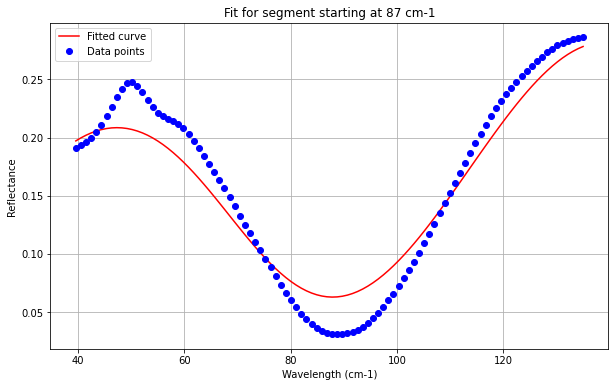

DEBUG - Segment: wavelength range 58.8 to 154.3


popt= [20.14948785 13.67259413], perr= [0.33045091 0.46548892], wl_begin = 106.5751726688


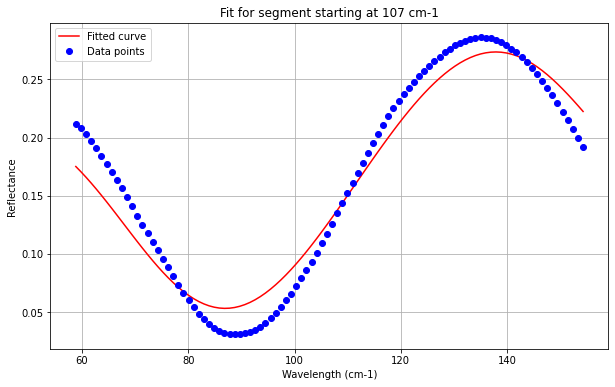

DEBUG - Segment: wavelength range 78.1 to 173.6


popt= [20.62564832  9.34012741], perr= [0.30095762 0.38615583], wl_begin = 125.86479668125


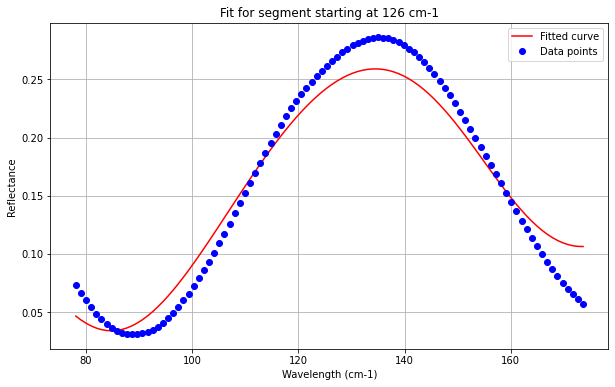

DEBUG - Segment: wavelength range 97.4 to 192.9


popt= [18.14966151  9.01153977], perr= [0.46707882 0.63835839], wl_begin = 145.1544206937


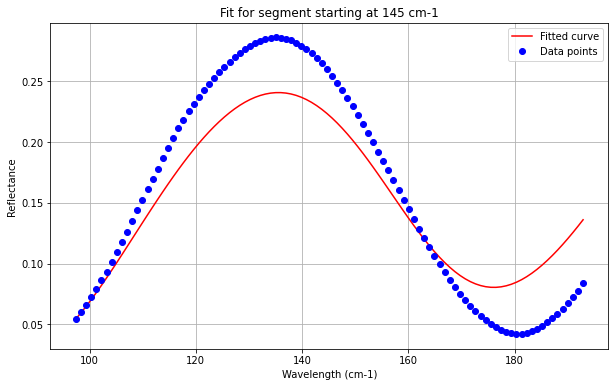

DEBUG - Segment: wavelength range 116.7 to 212.2


popt= [16.51350002  9.80093308], perr= [0.41596466 0.61331123], wl_begin = 164.44404470615


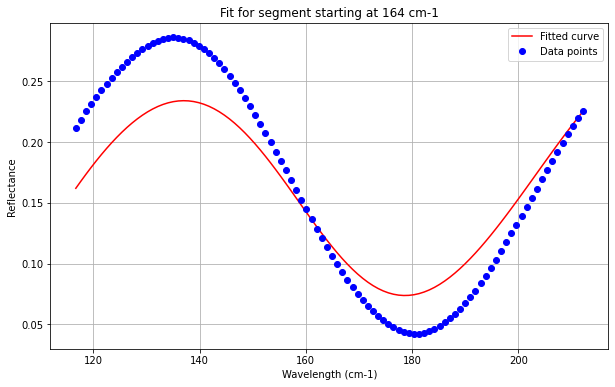

KeyboardInterrupt: 

In [35]:
def reflect_fitting(reflect_dict,
                 interval, step, 
                 segmentation_method='fixed',  # or 'inflection'
                 draw_plots=True,
                 output_curve_fit=None): 
    
    """
    Fit reflectance data for different graphene thicknesses.
    
    Parameters:
        interval (float): Window size for data segmentation
        step (float): Step size between windows
        segmentation_method (str): 'fixed' or 'inflection'


    for name in reflect_dict: # loop over thickness  


    """


    for name in reflect_dict: # loop over thickness  
        gr_thk = reflect_dict[name][2]
        assert 0 < gr_thk and gr_thk <1e-5
        logger.info(f"gr_thk= {gr_thk:.2e}m")
        fit_reflect = create_fit_function(gr_thk, 'R')
        wl_rc_arr, R_arr = (reflect_dict[name][0].to_numpy(), reflect_dict[name][1].to_numpy())
        logger.debug(f"(wl, R): {list(zip(wl_rc_arr, R_arr))}")
        
        wl_begins = [] # x-axis: list of middle points in segments
        fit_ngr_re = [] 
        fit_ngr_im = []
        
        # by fixed windows and steps
        if (segmentation_method == 'fixed'):
            wl_segments = make_2d_windows_vectorized(wl_rc_arr, interval, step)
            R_segments = make_2d_windows_vectorized(R_arr, interval, step)
   
        
        # by inflection points manually
        if(segmentation_method=='inflection'):  
            logger.error("Inflection segmentation method is not yet implemented.")
            wl_segments = wc_rc_arr
            R_segments = R_arr

        for x_data, y_data in zip(wl_segments, R_segments):
            try:
                popt, pcov = curve_fit(fit_reflect, x_data, y_data)
            except RuntimeError as e:
                logger.error(f"Fitting failed for segment at {wl_bgn}")
                raise e
        
            _perr = np.sqrt(np.diag(pcov))
            wl_bgn = 0.5*(x_data[0]+x_data[-1])
            logger.debug(f"Segment: wavelength range {x_data[0]:.1f} to {x_data[-1]:.1f}")
            print(f"popt= {popt}, perr= {_perr}, wl_begin = {wl_bgn}")
            wl_begins.append(wl_bgn)
            fit_ngr_re.append(popt[0])
            fit_ngr_im.append(popt[1])
            
            # Plot each fit segment

            if draw_plots:
                if not np.all([x_data, y_data]):
                    logger.error("Empty data for plotting")
                else:
                    plt.figure(figsize=(10, 6))
                    
                    plt.plot(x_data, fit_reflect(x_data, popt[0], popt[1]), 'r-', label='Fitted curve')
                    plt.plot(x_data, y_data, 'bo', label='Data points')
                    plt.xlabel('Wavelength (cm-1)')
                    plt.ylabel('Reflectance')
                    plt.title(f'Fit for segment starting at {wl_bgn:.0f} cm-1')
                    plt.legend()
                    plt.grid(True)
                    plt.show()
        wl_begins, fit_ngr_re, fit_ngr_im = np.array((wl_begins, fit_ngr_re, fit_ngr_im))
        wl_axis = 1e5/(wl_begins+interval*0.5)
        logger.debug(f"wl_begins = {wl_begins}")
        logger.debug(f"wl_axis = {wl_axis}") 

        # Plot final results
        plt.figure(figsize=(12, 6))
        fit_eps_gr_re = fit_ngr_re**2-fit_ngr_im**2
        fit_eps_gr_im = 2*fit_ngr_re*fit_ngr_im
        logger.debug(f"{fit_eps_gr_re}\n {fit_eps_gr_im} \n {wl_axis}\n")
        if not np.all([fit_eps_gr_re, fit_eps_gr_im, wl_begins]):
            logger.error("Empty data for plotting")
        plt.plot(wl_begins, fit_eps_gr_re, 'r-', label='Real part of epsilon')
        plt.plot(wl_begins, fit_eps_gr_im, 'b-', label='Imaginary part of epsilon')
        plt.xlabel('Wavelength (cm-1)')
        plt.ylabel('Refractive index')
        plt.title(f'Fitted refractive index components for {name}')
        plt.legend()
        plt.grid(True)
        plt.show() 

reflect_fitting(reflect_dict, 100, 20, draw_plots=True)




## Fit Transmit

In [ ]:
def transmit_fitting(transmit_dict,
                 interval, step, 
                 segmentation_method='fixed',  # or 'inflection'
                 draw_plots=True,
                 output_curve_fit=None): 
    
    """
    Fit Transmittance data for different graphene thicknesses.
    
    Parameters:
        interval (float): Window size for data segmentation
        step (float): Step size between windows
        segmentation_method (str): 'fixed' or 'inflection'


    for name in transmit_dict: # loop over thickness  


    """


    for name in transmit_dict: # loop over thickness  
        gr_thk = transmit_dict[name][2]
        assert 0 < gr_thk and gr_thk <1e-5
        logger.info(f"gr_thk= {gr_thk:.2e}m")
        fit_reflect = create_fit_function(gr_thk, 'T')
        wl_rc_arr, T_arr = (transmit_dict[name][0].to_numpy(), 
                            transmit_dict[name][1].to_numpy())
        logger.debug(f"(wl, T): {list(zip(wl_rc_arr, T_arr))}")
        
        wl_begins = [] # x-axis: list of middle points in segments
        fit_ngr_re = [] 
        fit_ngr_im = []
        
        # by fixed windows and steps
        if (segmentation_method == 'fixed'):
            wl_segments = make_2d_windows_vectorized(wl_rc_arr, interval, step)
            T_segments = make_2d_windows_vectorized(T_arr, interval, step)
   
        
        # by inflection points manually
        if(segmentation_method=='inflection'):  
            logger.error("Inflection segmentation method is not yet implemented.")
            wl_segments = wc_rc_arr
            T_segments = T_arr

        for x_data, y_data in zip(wl_segments, T_segments):
            try:
                popt, pcov = curve_fit(fit_reflect, x_data, y_data)
            except RuntimeError as e:
                logger.error(f"Fitting failed for segment at {wl_bgn}")
                raise e
        
            _perr = np.sqrt(np.diag(pcov))
            wl_bgn = 0.5*(x_data[0]+x_data[-1])
            logger.debug(f"Segment: wavelength range {x_data[0]:.1f} to {x_data[-1]:.1f}")
            print(f"popt= {popt}, perr= {_perr}, wl_begin = {wl_bgn}")
            wl_begins.append(wl_bgn)
            fit_ngr_re.append(popt[0])
            fit_ngr_im.append(popt[1])
            
            # Plot each fit segment

            if draw_plots:
                if not np.all([x_data, y_data]):
                    logger.error("Empty data for plotting")
                else:
                    plt.figure(figsize=(10, 6))
                    
                    plt.plot(x_data, fit_reflect(x_data, popt[0], popt[1]), 'r-', label='Fitted curve')
                    plt.plot(x_data, y_data, 'bo', label='Data points')
                    plt.xlabel('Wavelength (cm-1)')
                    plt.ylabel('Transmittance')
                    plt.title(f'Fit for segment starting at {wl_bgn:.0f} cm-1')
                    plt.legend()
                    plt.grid(True)
                    plt.show()
        wl_begins, fit_ngr_re, fit_ngr_im = np.array((wl_begins, fit_ngr_re, fit_ngr_im))
        wl_axis = 1e5/(wl_begins+interval*0.5)
        logger.debug(f"wl_begins = {wl_begins}")
        logger.debug(f"wl_axis = {wl_axis}") 

        # Plot final results
        plt.figure(figsize=(12, 6))
        fit_eps_gr_re = fit_ngr_re**2-fit_ngr_im**2
        fit_eps_gr_im = 2*fit_ngr_re*fit_ngr_im
        logger.debug(f"{fit_eps_gr_re}\n {fit_eps_gr_im} \n {wl_axis}\n")
        if not np.all([fit_eps_gr_re, fit_eps_gr_im, wl_begins]):
            logger.error("Empty data for plotting")
        plt.plot(wl_begins, fit_eps_gr_re, 'r-', label='Real part of epsilon')
        plt.plot(wl_begins, fit_eps_gr_im, 'b-', label='Imaginary part of epsilon')
        plt.xlabel('Wavelength (cm-1)')
        plt.ylabel('Refractive index')
        plt.title(f'Fitted refractive index components for {name}')
        plt.legend()
        plt.grid(True)
        plt.show() 

transmit_fitting(transmit_dict, 100, 20, draw_plots=True)




In [ ]:
# extract dependence epsilon(thickness)



# Test gold Drude pseudo-data
$1-w_p^2/(w^2+w_t^2) + i*w_t*w_p^2/(w*(w^2+w_t^2))$

##
```
 
w = 1.34e13 s-1
wp = 1.37e16 s-1
wt = 4.05e13 s-1
```

## Generate data

In [132]:
# Generate data

def drude_epsilon(wl_rc_arr, wp, wt):

    """
    wl_rc_arr - array of wls[cm-1]
    wp - plasma frequency [s-1]
    wt - [s-1]
    returns float epsilon
    """
    
    c = 3e10 # cm
    w_arr = 2*pi*c*wl_rc_arr
    epsilon = 1 - wp**2/(w_arr**2 + wt**2) + 1j*wt*wp**2/(w_arr*(w_arr**2 + wt**2))
    return epsilon


def generate_drude_spectrum(wl_rc_arr, wp, wt, thk, mode, filename, path, 
                            noise_ampl=0.001, draw_plot=False):

    """
    wl_rc_arr - array of wls[cm-1]

    returns 1d-array noisy spectrum

    """

    epsilon = drude_epsilon(wl_rc_arr, wp, wt)
    n = sqrt(epsilon)
    
    if draw_plot:
        plt.figure(figsize=(10,6))
        plt.plot(wl_rc_arr, epsilon.real, label='Re(ε)')
        plt.plot(wl_rc_arr, epsilon.imag, label='Im(ε)')
        plt.xlabel('Wavenumber (cm⁻¹)')
        plt.ylabel('ε')
        plt.legend()
        plt.grid(True)
        plt.show()


    def spectrum_elem(wl, n, d, mode): 
        if(mode=='R'):
            th_0 = pi/4
        if(mode=='T'):
            th_0 = 0
        
        #lists for coh_tmm with PP from experiment 
        n_list = [1, n, 1.498+1j*14e-4, 1]  
        d_list = np.array([np.inf, d, 40.5e-6, np.inf])  
        result = 0.5*(coh_tmm(pol='s', n_list=n_list, d_list=d_list, th_0 = th_0, lam_vac=wl)[mode] 
             +coh_tmm(pol='p', n_list=n_list, d_list=d_list, th_0 = th_0, lam_vac=wl)[mode])
        
        if False:
            logger.debug(f"result={result}")
        
        return result

    logger.debug(f"(wl[cm-1], n) {list(zip(wl_rc_arr, n))}")
    pure_spectrum = np.array([spectrum_elem(0.01/wl_rc, ni, thk, mode) for ni, wl_rc in zip(wl_rc_arr, n)])
    noise = noise_ampl*np.random.normal(0, 1, len(wl_rc_arr))
    spectrum = np.array(pure_spectrum + noise)
    logger.debug(f"spectrum = {spectrum}")
    # Save spectrum data to CSV file
 
    output_data = pd.DataFrame([wl_rc_arr, spectrum]).T
    output_data.to_csv(os.path.join(path, filename), header=False, index=False, sep='\t')










DEBUG - (wl[cm-1], n) [(5.0, (1549.4308040342162+1585.9068577108594j)), (6.0, (1410.9757412575952+1450.9273095493227j)), (7.0, (1303.0914107268818+1346.2364488035457j)), (8.0, (1215.9015555259+1262.0161863093715j)), (9.0, (1143.4902464702384+1192.3909592726022j)), (10.0, (1082.068786521153+1133.601430673604j)), (11.0, (1029.0833433585342+1083.1159070546007j)), (12.0, (982.7412740386674+1039.158923396786j)), (13.0, (941.7421586299431+1000.4437017284827j)), (14.0, (905.116576914792+966.0118663933395j)), (15.0, (872.1250706747675+935.1330472129148j)), (16.0, (842.1924200055424+907.2396068381519j)), (17.0, (814.8635148440507+881.8828379796959j)), (18.0, (789.7729066465348+858.7027555570775j)), (19.0, (766.6232944198057+837.4067637360524j)), (20.0, (745.1700030523357+817.754272839033j)), (21.0, (725.2095760421581+799.5453997788484j)), (22.0, (706.5712526517286+782.6125300559248j)), (23.0, (689.1105051981044+766.8139226915084j)), (24.0, (672.7040725883203+752.0287982839435j)), (25.0, (657.24

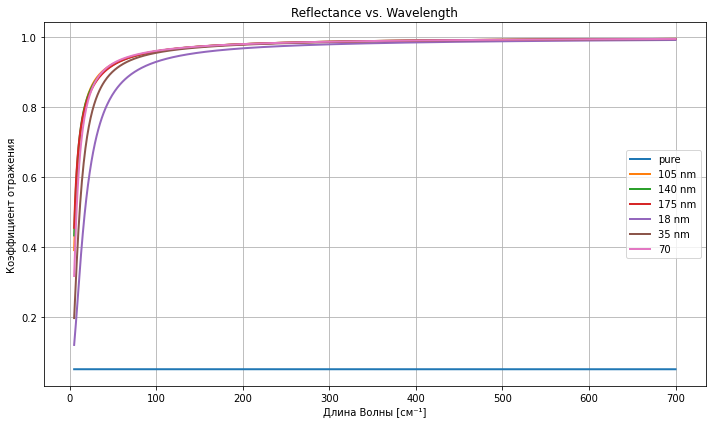

In [145]:
# Reflect gold files processing

for thk in np.array([0, 0.5, 1, 2, 3, 4, 5])*35e-9:
    generate_drude_spectrum(wl_rc_arr=np.linspace(5, 700, 696),
                            wp = 1.37e16,
                            wt = 4.05e13,
                            thk = thk, 
                            mode = 'R', 
                            filename = f"{thk:.2e}"+'_gold_40mkm_PP_reflect.csv', 
                            path = r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Gold_simulated_R",
                            noise_ampl=0,
                            draw_plot=False)
r_gold_dict=load_r_data(path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Gold_simulated_R",
            extension='.csv', 
            draw_plot=True, 
            labels = ['pure', '105 nm', '140 nm', '175 nm', '18 nm', '35 nm', '70'], 
            reverse=False)




DEBUG - (wl[cm-1], n) [(5.0, (1549.4308040342162+1585.9068577108594j)), (6.158333333333333, (1392.1773834761584+1432.6516039187125j)), (7.316666666666666, (1273.5796387814441+1317.6870778636267j)), (8.475000000000001, (1179.9323182895869+1227.3912160023397j)), (9.633333333333333, (1103.4954550250313+1154.0794312743928j)), (10.791666666666668, (1039.523256836228+1093.0449842012006j)), (11.950000000000001, (984.9222209727369+1041.2231209618415j)), (13.108333333333334, (937.5780057904906+996.5213819346085j)), (14.266666666666667, (895.9897749470804+957.4560364918686j)), (15.425, (859.0587101376799+922.9419334202588j)), (16.583333333333336, (825.9593215225499+892.164703146902j)), (17.741666666666667, (796.0577821845119+864.4997073119024j)), (18.900000000000002, (768.8582393773279+839.458786633328j)), (20.058333333333337, (743.9664369857798+816.6542009741257j)), (21.21666666666667, (721.06441618147+795.7735659844611j)), (22.375, (699.8925153422168+776.5620316409451j)), (23.533333333333335, 

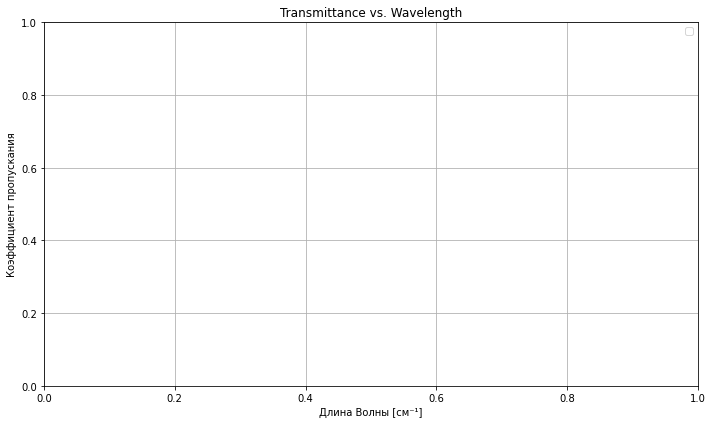

In [146]:
# Transmit 
for thk in np.array([0, 0.5, 1, 2, 3, 4, 5])*35e-9:
    generate_drude_spectrum(wl_rc_arr=np.linspace(5, 700, 601),
                            wp = 1.37e16,
                            wt = 4.05e13,
                            thk = thk, 
                            mode = 'T', 
                            filename = f"{thk:.2e}"+'_gold_40mkm_PP_transmit.csv', 
                            path = r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Gold_simulated_T",
                            noise_ampl=0,
                            draw_plot=False
                           )
t_gold_dict=load_t_data(path=r"C:\Users\belco\Documents\Graphene\Data\Dispersion_PP_40\Gold_simulated_T",
            draw_plot=True,
            extension='.csv',
            thk_arr_rf= np.array([0.5, 1, 2, 3, 4, 5, 0])*35e-9,
            labels = ['pure', '105 nm', '140 nm', '175 nm', '18 nm', '35 nm', '70'], 
            reverse = False)


# Plot drude_epsilon




##  Approximation procedure

In [43]:
# Fit gold pseudo data
def gold_fitting(thk, mode, interval, step, wp, wt, print = True, draw_spect=True, draw_eps=True):
    wl_rc_arr = np.linspace(5, 700, 696)
    spectr = generate_drude_spectrum(wl_rc_arr, wp, wt, thk, mode)
    fit_function = create_fit_function(thk, mode)


    wl_segments = make_2d_windows_vectorized(wl_rc_arr, interval, step)
    spectr_segments = make_2d_windows_vectorized(spectr, interval, step)       
    
    for x_data, y_data in zip(wl_segments, spectr_segments):
        try:
            popt, _pcov = curve_fit(fit_reflect, x_data, y_data)
        except RuntimeError as e:
            logger.error(f"Fitting failed for segment at {wl_bgn}")
            continue
        
        _popt, _pcov = curve_fit(fit_reflect, x_data, y_data)
        _perr = np.sqrt(np.diag(_pcov))
        wl_bgn = 0.5*(x_data[0]+x_data[-1])
        print('popt=', _popt,  'perr=', _perr,  'gr_thk=', gr_thk,  'wl_begin = ', wl_bgn)
        wl_begins += [wl_bgn]
        fit_ngr_re += [_popt[0]]
        fit_ngr_im += [_popt[1]]
        
        # Plot each fit segment
        plt.figure(figsize=(10, 6))
        plt.plot(x_data, fit_reflect(x_data, _popt[0], _popt[1]), 'r-', label='Fitted curve')
        plt.plot(x_data, y_data, 'bo', label='Data points')
        plt.xlabel('Wavelength (cm-1)')
        plt.ylabel('Reflectance')
        plt.title(f'Fit for segment starting at {wl_bgn:.0f} cm-1')
        plt.legend()
        plt.grid(True)
        plt.show()
            

    if draw_eps:
        epsilon = drude_epsilon(wl_rc_arr, wp, wt)
        plt.figure()
        plt.plot(0.01/wl_rc_arr, epsilon.real, label='Real part of epsilon')
        plt.plot(0.01/wl_rc_arr, epsilon.imag, label='Imaginary part of epsilon')
        plt.xlabel('Wavelength [cm]')
        plt.ylabel('Epsilon')
        plt.legend()
        plt.title('Drude Epsilon vs Wavelength')
        plt.show()






    


In [ ]:
gold_fitting(30e-9, 'R', 
             interval = 20,
             step = 20,
             wp = 1.37e16,
             wt = 4.05e13)